<a href="https://colab.research.google.com/github/sadichyaa/Assesment1/blob/main/Worksheet5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

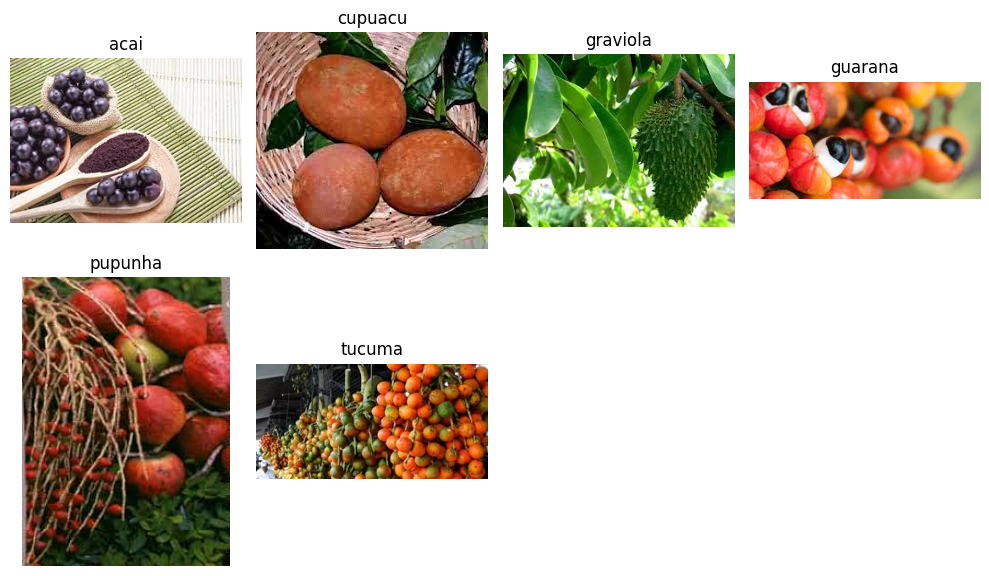

In [ ]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# Path to dataset
train_dir = "/content/drive/MyDrive/AI ML/Data/FruitinAmazon/train/"

# Get class names (subfolders)
classes = os.listdir(train_dir)

images = []
labels = []

# Pick one random image from each class
for cls in classes:
    cls_path = os.path.join(train_dir, cls)
    img_name = random.choice(os.listdir(cls_path))
    img_path = os.path.join(cls_path, img_name)

    img = Image.open(img_path)
    images.append(img)
    labels.append(cls)

# Plot images (2 rows)
plt.figure(figsize=(10, 6))
for i in range(len(images)):
    plt.subplot(2, len(images)//2 + 1, i+1)
    plt.imshow(images[i])
    plt.title(labels[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
  import tensorflow as tf

  img_height = 128
  img_width = 128
  batch_size = 32
  validation_split = 0.2

  # Normalize
  rescale = tf.keras.layers.Rescaling(1./255)

  # Training dataset
  train_ds = tf.keras.preprocessing.image_dataset_from_directory(
      train_dir,
      labels='inferred',
      label_mode='int',
      image_size=(img_height, img_width),
      batch_size=batch_size,
      shuffle=True,
      validation_split=validation_split,
      subset='training',
      seed=123
  )

  train_ds = train_ds.map(lambda x, y: (rescale(x), y))

  # Validation dataset
  val_ds = tf.keras.preprocessing.image_dataset_from_directory(
      train_dir,
      labels='inferred',
      label_mode='int',
      image_size=(img_height, img_width),
      batch_size=batch_size,
      shuffle=False,
      validation_split=validation_split,
      subset='validation',
      seed=123
  )

  val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


In [ ]:
from tensorflow.keras import layers, models

num_classes = len(os.listdir(train_dir))

model = models.Sequential([
    # Conv Layer 1
    layers.Conv2D(32, (3,3), padding='same', activation='relu',
                  input_shape=(128,128,3)),
    layers.MaxPooling2D((2,2)),

    # Conv Layer 2
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Flatten
    layers.Flatten(),

    # Fully Connected
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),

    # Output
    layers.Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

checkpoint = ModelCheckpoint("best_model.h5",
                             monitor='val_accuracy',
                             save_best_only=True)

early_stop = EarlyStopping(patience=10,
                           restore_best_weights=True)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    batch_size=16,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1453 - loss: 2.1339

3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 3s/step - accuracy: 0.1389 - loss: 2.3305 - val_accuracy: 0.0000e+00 - val_loss: 1.8930
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 0.2135 - loss: 1.8799

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 600ms/step - accuracy: 0.2500 - loss: 1.8377 - val_accuracy: 0.8333 - val_loss: 1.3909
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 490ms/step - accuracy: 0.3889 - loss: 1.6806 - val_accuracy: 0.1111 - val_loss: 1.6675
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 438ms/step - accuracy: 0.3472 - loss: 1.5201 - val_accuracy: 0.0556 - val_loss: 1.6971
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 504ms/step - accuracy: 0.4722 - loss: 1.3151 - val_accuracy: 0.7778 - val_loss: 1.1005
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 528ms/step - accuracy: 0.5833 - loss: 1.0542 - val_accuracy: 0.3889 - val_loss: 1.6364
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 793ms/step - accuracy: 0.8472 - loss: 0.8653 - val_accuracy: 0.8333 - val_loss: 0.6533
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 515ms/step - accuracy: 0.9444 - loss: 0.6086 - val_accuracy: 0.7778 - val_loss: 0.7725
Epoch 9/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 519ms/step - accuracy: 0.8889 - loss: 0.4886 - val_accuracy: 0.7222 - val_loss: 0.7

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 542ms/step - accuracy: 1.0000 - loss: 0.0145 - val_accuracy: 0.8889 - val_loss: 0.3831
Epoch 17/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 688ms/step - accuracy: 1.0000 - loss: 0.0089 - val_accuracy: 0.8889 - val_loss: 0.4457
Epoch 18/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 654ms/step - accuracy: 1.0000 - loss: 0.0042 - val_accuracy: 0.8333 - val_loss: 0.5228
Epoch 19/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 1.0000 - loss: 0.0033 - val_accuracy: 0.8333 - val_loss: 0.5937
Epoch 20/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 489ms/step - accuracy: 1.0000 - loss: 0.0031 - val_accuracy: 0.8333 - val_loss: 0.6448
Epoch 21/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 517ms/step - accuracy: 1.0000 - loss: 0.0021 - val_accuracy: 0.8333 - val_loss: 0.6618
Epoch 22/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 546ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 0.8333 - val_loss: 0.6632
Epoch 23/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 485ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 0.8333 - val_loss:

In [ ]:
test_loss, test_acc = model.evaluate(val_ds)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - accuracy: 0.8333 - loss: 0.3680
Test Accuracy: 0.8333333134651184
Test Loss: 0.36800140142440796


In [ ]:
# Save
model.save("final_model.h5")

# Load
from tensorflow.keras.models import load_model
loaded_model = load_model("final_model.h5")

# Evaluate again
loaded_model.evaluate(val_ds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 594ms/step - accuracy: 0.8333 - loss: 0.3680


[0.36800140142440796, 0.8333333134651184]

In [ ]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = loaded_model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

print(classification_report(y_true, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         0
           4       0.67      0.67      0.67         3
           5       0.93      0.87      0.90        15

    accuracy                           0.83        18
   macro avg       0.53      0.51      0.52        18
weighted avg       0.88      0.83      0.86        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


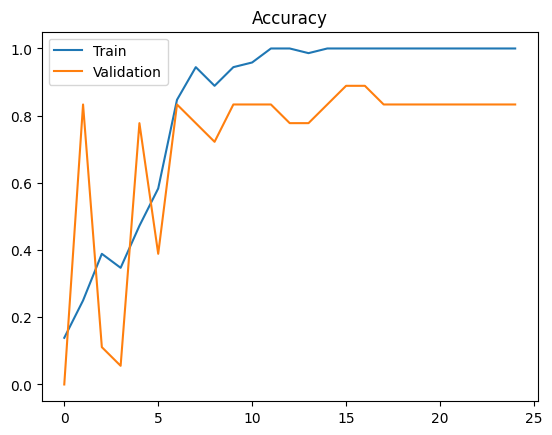

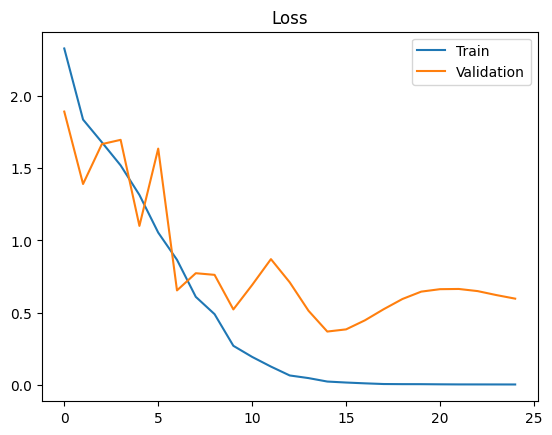

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.legend(['Train', 'Validation'])
plt.show()